In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [32]:
from sklearn.ensemble import GradientBoostingRegressor

In [39]:
from sklearn.linear_model import LinearRegression

In [41]:
from sklearn.neural_network import MLPRegressor

In [42]:
from sklearn.svm import SVR

In [45]:
from catboost import CatBoostRegressor

In [12]:
df1 = pd.read_csv("spotify_tracks.csv")
df2 = pd.read_csv("lyrics_features.csv")

In [13]:
pd.set_option('display.max_columns', None)

In [14]:
csv1.head()

,Unnamed: 0,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,energy,href,id,instrumentalness,key,liveness,loudness,lyrics,mode,name,playlist,popularity,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,0.606,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.151,-7.447,\r\n\r\nPerhaps I am bound to be restless\r\nA...,0.0,Blood,Hipsteribrunssi,28.0,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,0.308,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,3VAX2MJdmdqARLSU5hPMpm,0.000000,6.0,0.253,-10.340,\r\nYour Gods and my Gods-do you or I know whi...,1.0,The Ugly Duckling,Animal Stories,31.0,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,0.931,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,1L3YAhsEMrGVvCgDXj2TYn,0.000000,4.0,0.938,-13.605,"\r\n\r\nClosed off from love, I didn't need th...",0.0,Jimmy Launches His Own Range Of Greetings Cards,Best Of British Comedy,31.0,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,0.126,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,6aCe9zzoZmCojX7bbgKKtf,0.000000,3.0,0.113,-20.254,"\r\nPAIN, n. An uncomfortable frame of mind th...",0.0,The Crime At Pickets Mill,Short Stories,14.0,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,0.942,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,1Vo802A38tPFHmje1h91um,0.000000,7.0,0.917,-13.749,"\r\n\r\nClosed off from love, I didn't need th...",1.0,Setup + Punchline = Joke,Best Of British Comedy,32.0,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track


In [15]:
csv2.head()

,Unnamed: 0,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth
0,0,-1.00,-1.00,-1,-1,-1.000000,5KIfHjHI5NIsPHNt58qua0,-1.00
1,1,1.10,5.65,31,326,0.043011,13keyz9ikBe6ZpRasw7l4X,0.45
2,2,1.37,4.77,74,532,0.050352,1WugzepXsLjnsM0K4UaWYc,0.59
3,3,1.95,3.38,72,430,0.028560,2MO6oEAlMKcsfI8xP3yoy8,0.49
4,4,1.16,2.99,68,368,0.047849,1i4St7fmSUE9nB3R9n8fol,0.47


In [16]:
df2_clean = df2[df2['mean_syllables_word'] != -1].copy()

df1_popularity = df1[['id', 'popularity']].copy()

df = pd.merge(
    df2_clean, 
    df1_popularity, 
    left_on='track_id', 
    right_on='id', 
    how='inner'
)

df = df.drop(columns=['id'])

columns_to_drop = [col for col in df.columns if 'Unnamed' in col]
df = df.drop(columns=columns_to_drop)

In [17]:
df.head()

,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth,popularity
0,1.10,5.65,31,326,0.043011,13keyz9ikBe6ZpRasw7l4X,0.45,52.0
1,1.37,4.77,74,532,0.050352,1WugzepXsLjnsM0K4UaWYc,0.59,55.0
2,1.95,3.38,72,430,0.028560,2MO6oEAlMKcsfI8xP3yoy8,0.49,46.0
3,1.16,2.99,68,368,0.047849,1i4St7fmSUE9nB3R9n8fol,0.47,36.0
4,1.32,4.21,39,256,0.040486,3UyfvY3Gs6d4wvq8O4ANqQ,0.60,6.0


In [30]:

feature_cols = [
    'mean_syllables_word',
    'mean_words_sentence',
    'n_sentences',
    'n_words',
    'sentence_similarity',
    'vocabulary_wealth'
]

clean_df = df.dropna(subset=feature_cols + ['popularity']).copy()

X = clean_df[feature_cols]
y = clean_df['popularity']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


=== Random Forest Performance ===
rmse: 13.2385
mae:    9.9149
r2: 0.4132



/var/folders/w1/j5xwrw0j3850qv6jk2xpmq_m0000gn/T/ipykernel_37486/2198768102.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


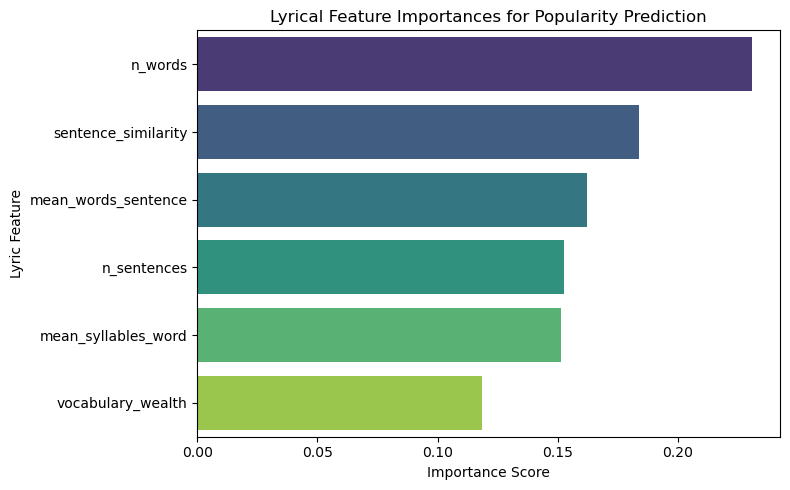

In [49]:

rf_model = RandomForestRegressor(n_estimators=250, random_state=10)
rf_model.fit(X_train_scaled, y_train)

preds = rf_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("=== Random Forest Performance ===")
print(f"rmse: {rmse:.4f}")
print(f"mae:    {mae:.4f}")
print(f"r2: {r2:.4f}\n")


importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Lyrical Feature Importances for Popularity Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Lyric Feature')
plt.tight_layout()
plt.show()


=== Random Forest Performance ===  (all features)
RMSE (Root Mean Squared Error): 13.2630
MAE  (Mean Absolute Error):    9.9282
R² Score:                       0.4111



=== gb Performance === (all features)
RMSE (Root Mean Squared Error): 15.2922
MAE  (Mean Absolute Error):    12.3210
R² Score:                       0.2171



In [36]:
gb_model = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.02, 
    max_depth=4, 
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingRegressor(learning_rate=0.02, max_depth=4, n_estimators=500,
                          random_state=42)

=== gb Performance ===
RMSE (Root Mean Squared Error): 15.2922
MAE  (Mean Absolute Error):    12.3210
R² Score:                       0.2171



/var/folders/w1/j5xwrw0j3850qv6jk2xpmq_m0000gn/T/ipykernel_37486/1612420303.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


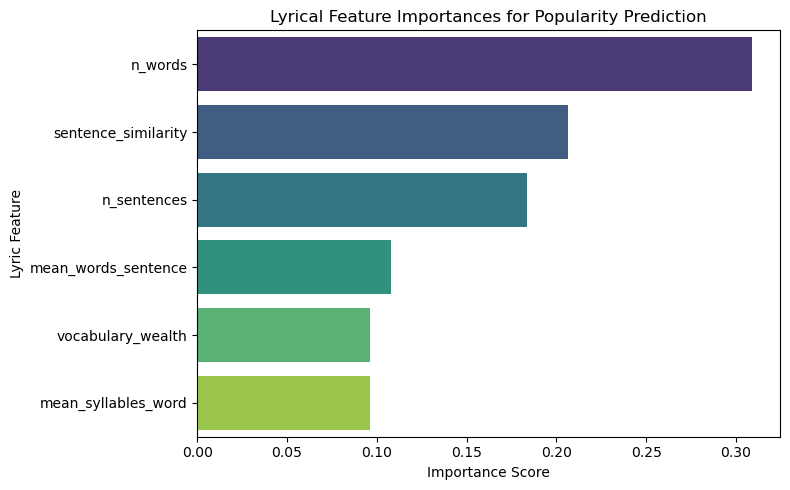

In [37]:
preds = gb_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("=== gb Performance ===")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE  (Mean Absolute Error):    {mae:.4f}")
print(f"R² Score:                       {r2:.4f}\n")


importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Lyrical Feature Importances for Popularity Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Lyric Feature')
plt.tight_layout()
plt.show()

In [46]:
models = {
    "SVR (RBF)": SVR(C=10.0),
    "MLP (Neural Net)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({"Model": name, "R2 Score": r2, "MAE": mae, "RMSE": rmse})

# Convert to DataFrame for quick visual comparison
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(results_df)

              Model  R2 Score        MAE       RMSE
1  MLP (Neural Net)  0.173566  12.582101  15.711266
0         SVR (RBF)  0.137759  12.747575  16.048026


In [ ]:
s